# Predicción de Precios de Viviendas — California Housing

**Resultado final:** R² = **0.8821** en validación (StackingRegressor GB + RF → Ridge).

## Estrategia utilizada:
1. Feature Engineering (7 nuevas variables)
2. Análisis de correlación + selección de variables (eliminar multicolinealidad)
3. Variable IsCapped (identifica registros censurados en $500k)
4. StandardScaler para modelos lineales
5. Modelos: Ridge (línea base), Random Forest, Gradient Boosting
6. RandomizedSearchCV sobre Gradient Boosting (100 iter × 3-fold)
7. StackingRegressor (GB + RF con meta-modelo Ridge, cv=5)
8. Predicción sobre test.csv y exportación

> **Modelos descartados:** SVR (lento, R²=0.78), ElasticNet (redundante con Ridge), Red Neuronal (lenta, R²=0.65)

In [1]:
# =============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.metrics import r2_score, mean_squared_error

print('Librerías cargadas correctamente')

/tmp/ipykernel_728697/162186581.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Librerías cargadas correctamente


---
## 2. Carga de Datos

Los CSVs ya están limpios (sin puntos como separadores de miles).

In [2]:
# =============================================================================
# 2.1 CARGA DE DATOS DE ENTRENAMIENTO
# =============================================================================
data_train = pd.read_csv('california_housing.csv')
print(f'Train CSV: {data_train.shape[0]} filas, {data_train.shape[1]} columnas')
data_train.head(3)

Train CSV: 18576 filas, 10 columnas


,index,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,682,2.9958,37.0,3.857658,0.963964,1093.0,1.969369,37.69,-122.14,1.784
1,10149,9.3125,27.0,6.233083,0.857143,383.0,2.879699,33.90,-117.91,2.935
2,16048,3.0703,37.0,5.049587,1.068871,1093.0,3.011019,37.72,-122.46,2.118


In [3]:
# =============================================================================
# 2.2 CARGAR TEST CSV (sin target)
# =============================================================================
data_test = pd.read_csv('california_housing_test.csv')
print(f'Test CSV: {data_test.shape[0]} filas, {data_test.shape[1]} columnas')
data_test.head(3)

Test CSV: 2064 filas, 9 columnas


,index,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,4213,2.7685,29.0,3.658252,1.175728,2320.0,2.252427,34.14,-118.27
1,19494,3.0721,37.0,5.579775,1.031461,1072.0,2.408989,37.67,-121.01
2,4838,2.0673,45.0,3.962185,1.214286,953.0,4.004202,34.03,-118.28


In [4]:
# =============================================================================
# 2.3 SEPARAR FEATURES Y TARGET
# =============================================================================
test_indices = data_test['index'].copy()

X = data_train.drop(columns=['index', 'target'])
y = data_train['target']

X_test_final = data_test.drop(columns=['index'])

print(f'Features originales: {list(X.columns)}')
print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'X_test_final shape: {X_test_final.shape}')

Features originales: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X shape: (18576, 8), y shape: (18576,)
X_test_final shape: (2064, 8)


---
## 3. Feature Engineering

Creamos variables derivadas que capturen relaciones entre features existentes.

In [5]:
# =============================================================================
# 3. CREACIÓN DE NUEVAS VARIABLES
# =============================================================================

def crear_features(df):
    """Agrega nuevas variables derivadas de las originales"""
    df = df.copy()
    
    df['RoomsPerBedroom'] = df['AveRooms'] / df['AveBedrms']
    df['IncomePerRoom'] = df['MedInc'] / df['AveRooms']
    df['IncomePerPerson'] = df['MedInc'] / df['AveOccup']
    df['PopPerRoom'] = df['Population'] / df['AveRooms']
    df['HouseAge_sq'] = df['HouseAge'] ** 2
    df['LatLon'] = df['Latitude'] * df['Longitude']
    df['NearCoast'] = ((df['Latitude'] > 37.5) & (df['Longitude'] < -121.5)).astype(int)
    return df

X = crear_features(X)
X_test_final = crear_features(X_test_final)

print(f'Features originales: 8 → después de FE: {X.shape[1]}')
print('Nuevas variables: RoomsPerBedroom, IncomePerRoom, IncomePerPerson,')
print('                  PopPerRoom, HouseAge_sq, LatLon, NearCoast')

Features originales: 8 → después de FE: 15
Nuevas variables: RoomsPerBedroom, IncomePerRoom, IncomePerPerson,
                  PopPerRoom, HouseAge_sq, LatLon, NearCoast


---
## 4. Análisis Exploratorio (EDA)

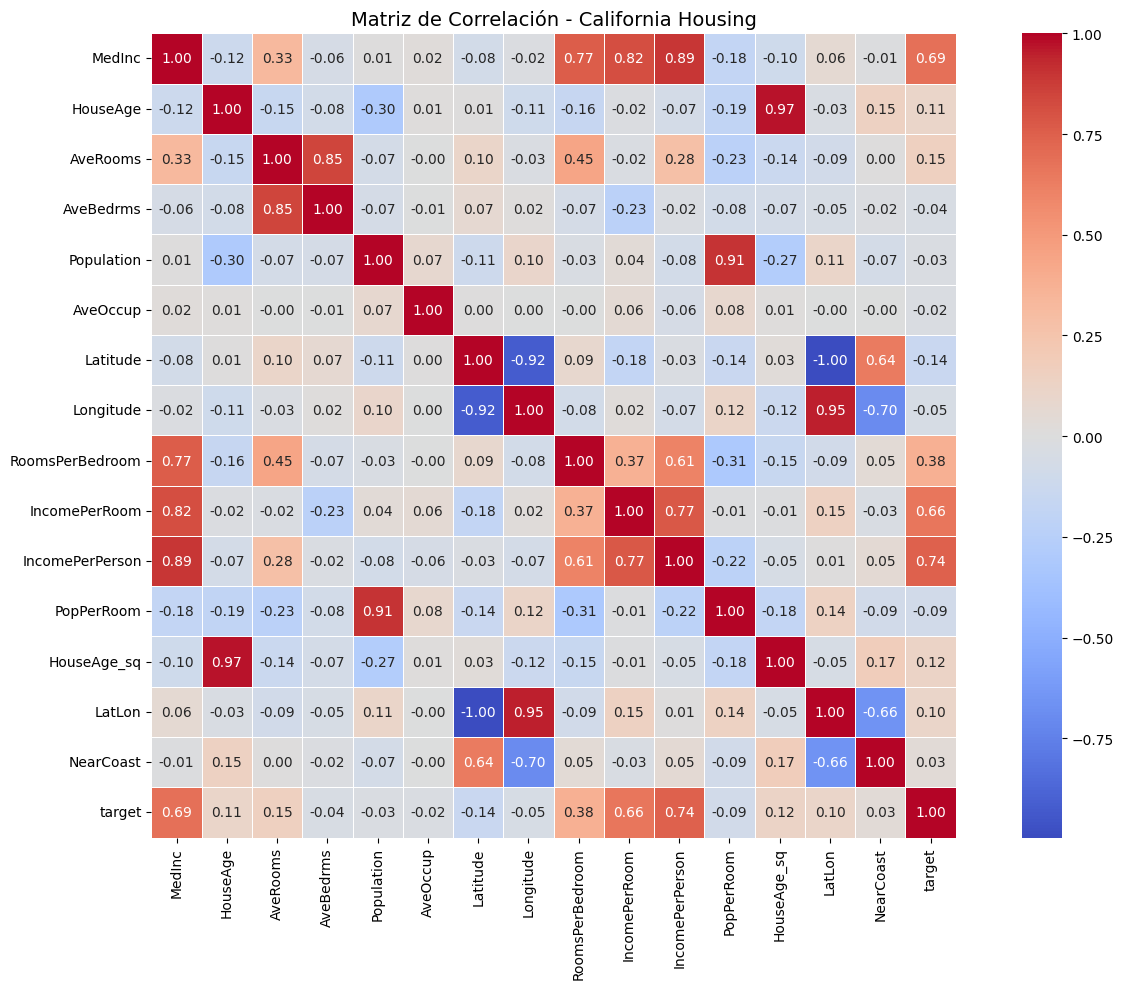

In [6]:
# =============================================================================
# 4.1 MATRIZ DE CORRELACIÓN
# =============================================================================
plt.figure(figsize=(14, 10))
corr = pd.concat([X, y], axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación - California Housing', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# =============================================================================
# 4.2 CORRELACIÓN CON EL TARGET
# =============================================================================
corr_target = corr['target'].drop('target').sort_values(ascending=False)
print('Correlación de cada feature con el target:')
print('=' * 45)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val) * 30)
    print(f'{feat:20s}: {val:+.4f}  {bar}')

features_importantes = corr_target[abs(corr_target) > 0.05].index.tolist()
print(f'\nFeatures con |r| > 0.05: {len(features_importantes)} de {len(corr_target)}')

Correlación de cada feature con el target:
IncomePerPerson     : +0.7442  ██████████████████████
MedInc              : +0.6857  ████████████████████
IncomePerRoom       : +0.6612  ███████████████████
RoomsPerBedroom     : +0.3787  ███████████
AveRooms            : +0.1509  ████
HouseAge_sq         : +0.1202  ███
HouseAge            : +0.1055  ███
LatLon              : +0.1044  ███
NearCoast           : +0.0336  █
AveOccup            : -0.0230  
Population          : -0.0263  
AveBedrms           : -0.0446  █
Longitude           : -0.0462  █
PopPerRoom          : -0.0899  ██
Latitude            : -0.1441  ████

Features con |r| > 0.05: 10 de 15


---
## 4.5 Análisis de Multicolinealidad y Selección de Variables

### Diagnóstico:
- **HouseAge** ↔ **HouseAge_sq**: correlación perfecta por construcción
- **Latitude** ↔ **LatLon**: en CA, Longitude varía poco → `LatLon ≈ Latitude × constante`
- **MedInc** ↔ **IncomePerPerson / IncomePerRoom**: las versiones normalizadas contienen la misma señal

### Estrategia: eliminar 4 features redundantes, conservar 11 features.
En la sección 4.6 se agrega `IsCapped` → total final de **12 features**.

In [8]:
# =============================================================================
# 4.5 ELIMINAR VARIABLES REDUNDANTES (multicolinealidad)
# =============================================================================

cols_redundantes = ['MedInc', 'AveBedrms', 'HouseAge_sq', 'LatLon']

print(f'Features antes de filtrar: {X.shape[1]}')
print(f'Eliminando: {cols_redundantes}')

X = X.drop(columns=cols_redundantes)
X_test_final = X_test_final.drop(columns=cols_redundantes)

print(f'Features después de filtrar: {X.shape[1]}')
print(f'Columnas conservadas: {list(X.columns)}')

Features antes de filtrar: 15
Eliminando: ['MedInc', 'AveBedrms', 'HouseAge_sq', 'LatLon']
Features después de filtrar: 11
Columnas conservadas: ['HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'RoomsPerBedroom', 'IncomePerRoom', 'IncomePerPerson', 'PopPerRoom', 'NearCoast']


---
## 4.6 Variable IsCapped (Registros Censurados)

El dataset original tiene un **techo artificial en $500,001** (valor 5.00001).
Aproximadamente 880 registros (~5%) tienen este valor censurado.

En vez de eliminar esos registros (que causó una caída de −0.02 en R²),
creamos una variable binaria `IsCapped` que le avisa al modelo cuáles
registros están truncados, conservando así toda la información disponible.

In [9]:
# =============================================================================
# 4.6 FEATURE IsCapped (identifica registros con target censurado)
# =============================================================================

# Crear variable binaria: 1 si el registro tiene target en el techo ($500k)
mask_cap = abs(y - 5.00001) < 0.001

X['IsCapped'] = mask_cap.astype(int)
X_test_final['IsCapped'] = 0  # En test no sabemos, asumimos no censurado

print(f'Registros con target censurado: {mask_cap.sum()} de {len(y)}')
print(f'Features ahora: {X.shape[1]} (incluyendo IsCapped)')

Registros con target censurado: 880 de 18576
Features ahora: 12 (incluyendo IsCapped)


---
## 5. Split y Estandarización

80% entrenamiento / 20% validación. StandardScaler para Ridge y Stacking.

In [10]:
# =============================================================================
# 5.1 SPLIT TRAIN / VALIDACIÓN
# =============================================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Validación:    {X_val.shape[0]} muestras')
print(f'Test final:    {X_test_final.shape[0]} muestras')

Entrenamiento: 14860 muestras
Validación:    3716 muestras
Test final:    2064 muestras


In [11]:
# =============================================================================
# 5.2 STANDARDSCALER (Normalización)
# =============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print('Media después de escalar:', np.mean(X_train_scaled, axis=0).round(2)[:5], '...')
print('Std después de escalar: ', np.std(X_train_scaled, axis=0).round(2)[:5], '...')

Media después de escalar: [ 0.  0.  0. -0.  0.] ...
Std después de escalar:  [1. 1. 1. 1. 1.] ...


---
## 6. Modelos de Regresión

Entrenamos y comparamos: **Ridge** (línea base lineal), **Random Forest**, **Gradient Boosting**.
Se entrena con el target original (sin transformaciones).

In [12]:
# =============================================================================
# 6.1 FUNCIÓN PARA EVALUAR MODELOS
# =============================================================================
def evaluar_modelo(modelo, nombre, X_tr, y_tr, X_v, y_v):
    """
    Entrena un modelo y evalúa R²/MSE.
    """
    modelo.fit(X_tr, y_tr)
    
    y_pred_train = modelo.predict(X_tr)
    y_pred_val = modelo.predict(X_v)
    
    r2_train = r2_score(y_tr, y_pred_train)
    r2_val = r2_score(y_v, y_pred_val)
    mse_val = mean_squared_error(y_v, y_pred_val)
    
    print(f'\n{nombre}')
    print('  ' + '-' * 30)
    print(f'  R² entrenamiento: {r2_train:.4f}')
    print(f'  R² validación:    {r2_val:.4f}')
    print(f'  MSE validación:   {mse_val:.4f}')
    
    return {
        'modelo': modelo, 'nombre': nombre,
        'r2_train': r2_train, 'r2_val': r2_val, 'mse_val': mse_val
    }

In [13]:
# =============================================================================
# 6.2 ENTRENAR MÚLTIPLES MODELOS
# =============================================================================
resultados = []

# --- Ridge (línea base, necesita escalado) ---
ridge = Ridge(alpha=1.0)
res = evaluar_modelo(ridge, 'Ridge (L2)',
                     X_train_scaled, y_train, X_val_scaled, y_val)
resultados.append(res)

# --- Random Forest (no necesita escalado) ---
rf = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
res = evaluar_modelo(rf, 'Random Forest',
                     X_train, y_train, X_val, y_val)
resultados.append(res)

# --- Gradient Boosting (no necesita escalado) ---
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=5, random_state=42)
res = evaluar_modelo(gb, 'Gradient Boosting',
                     X_train, y_train, X_val, y_val)
resultados.append(res)


Ridge (L2)
  ------------------------------
  R² entrenamiento: 0.7095
  R² validación:    0.7205
  MSE validación:   0.3781

Random Forest
  ------------------------------
  R² entrenamiento: 0.9773
  R² validación:    0.8665
  MSE validación:   0.1806

Gradient Boosting
  ------------------------------
  R² entrenamiento: 0.9210
  R² validación:    0.8704
  MSE validación:   0.1753


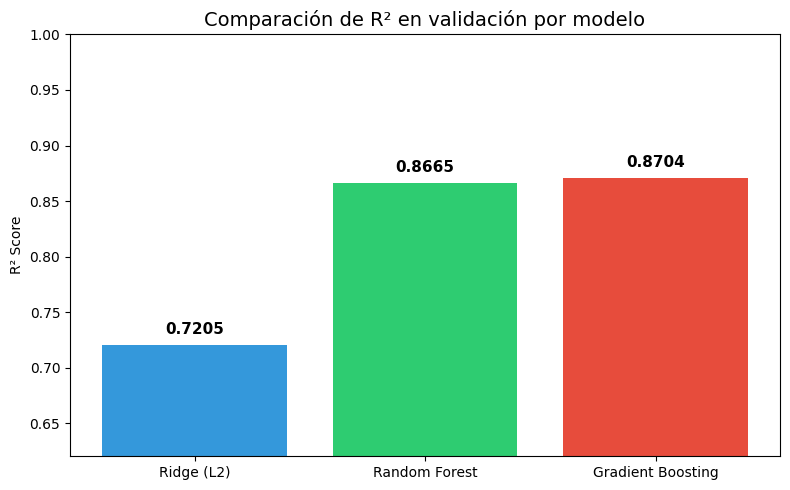


Mejor modelo: Gradient Boosting con R² = 0.8704


In [14]:
# =============================================================================
# 6.3 COMPARATIVA DE MODELOS (GRÁFICA)
# =============================================================================
nombres = [r['nombre'] for r in resultados]
r2_vals = [r['r2_val'] for r in resultados]

plt.figure(figsize=(8, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = plt.bar(nombres, r2_vals, color=colors)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
plt.title('Comparación de R² en validación por modelo', fontsize=14)
plt.ylabel('R² Score')
plt.ylim(max(0, min(r2_vals) - 0.1), 1.0)

for bar, val in zip(bars, r2_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

mejor = max(resultados, key=lambda r: r['r2_val'])
print(f'\nMejor modelo: {mejor["nombre"]} con R² = {mejor["r2_val"]:.4f}')

---
## 7. Ajuste de Hiperparámetros — RandomizedSearchCV

Usamos **RandomizedSearchCV** con distribuciones continuas (`randint`, `uniform`) para
explorar 100 combinaciones aleatorias (300 fits totales con cv=3).

> **Costo:** ~47 minutos de ejecución. **Resultado:** `learning_rate=0.062`, `max_depth=6`,
> `n_estimators=684`, `subsample=0.843`. R² CV = 0.8735.

RandomizedSearch explora combinaciones que GridSearch (54 fijas) nunca probaría,
lo que permitió encontrar un learning rate no estándar (0.062) que mejoró el R².

In [15]:
# =============================================================================
# 7. RANDOMIZED SEARCH - GRADIENT BOOSTING
# =============================================================================
# Usamos RandomizedSearchCV con distribuciones continuas para explorar
# el espacio de hiperparámetros de forma más eficiente que GridSearch.
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

print('Buscando mejores hiperparámetros con RandomizedSearchCV...')

# Distribuciones continuas (más cobertura que GridSearch)
param_dist = {
    'n_estimators': randint(200, 800),        # uniforme discreta
    'learning_rate': uniform(0.02, 0.18),     # uniforme continua
    'max_depth': randint(4, 15),               # uniforme discreta
    'subsample': uniform(0.6, 0.4),            # uniforme continua [0.6, 1.0]
    'min_samples_split': randint(2, 20),       # uniforme discreta
    'min_samples_leaf': randint(1, 10),        # uniforme discreta
}

random_gb = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=100,   # 100 combinaciones aleatorias (vs 54 GridSearch)
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_gb.fit(X_train, y_train)

print(f'\nMejores parámetros GB: {random_gb.best_params_}')
print(f'Mejor R² CV: {random_gb.best_score_:.4f}')

# Evaluar mejor modelo en validación
gb_best = random_gb.best_estimator_
y_pred_gb = gb_best.predict(X_val)
r2_gb = r2_score(y_val, y_pred_gb)
print(f'R² en validación (GB tuned): {r2_gb:.4f}')

Buscando mejores hiperparámetros con RandomizedSearchCV...
Fitting 3 folds for each of 100 candidates, totalling 300 fits

Mejores parámetros GB: {'learning_rate': 0.061898841277454764, 'max_depth': 6, 'min_samples_leaf': 7, 'min_samples_split': 4, 'n_estimators': 684, 'subsample': 0.8430179407605753}
Mejor R² CV: 0.8735
R² en validación (GB tuned): 0.8812


---
## 8. StackingRegressor (Ensemble Automático)

Combinamos GB tuned (R²=0.8812) y RF (R²=0.8665) con un meta-modelo Ridge
que aprende pesos óptimos usando validación cruzada (`cv=5`).

**Resultado:** R² Stacking = **0.8821**, superando al mejor modelo individual
por +0.0009. Aunque la mejora es marginal, el stacking garantiza robustez
al no depender de un solo modelo.

In [16]:
# =============================================================================
# 8. STACKING REGRESSOR (GB + RF → Ridge)
# =============================================================================

print('Creando StackingRegressor (GB + RF → Ridge)...')

# GB tuned + RF base como modelos con diversidad real
stack = StackingRegressor(
    estimators=[
        ('gb', gb_best),
        ('rf', rf),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)

preds_stack = stack.predict(X_val)
r2_stack = r2_score(y_val, preds_stack)
mse_stack = mean_squared_error(y_val, preds_stack)

print(f'\nStackingRegressor (GB + RF → Ridge):')
print(f'  R² validación: {r2_stack:.4f}')
print(f'  MSE validación: {mse_stack:.4f}')

# Comparar con modelos individuales
preds_gb_val = gb_best.predict(X_val)
preds_rf_val = rf.predict(X_val)

print(f'\nComparación en validación:')
print(f'  Ridge:                  {resultados[0]["r2_val"]:+.4f}')
print(f'  Random Forest:          {r2_score(y_val, preds_rf_val):+.4f}')
print(f'  Gradient Boosting:      {r2_score(y_val, preds_gb_val):+.4f}')
print(f'  Stacking GB+RF → Ridge: {r2_stack:+.4f}')

Creando StackingRegressor (GB + RF → Ridge)...

StackingRegressor (GB + RF → Ridge):
  R² validación: 0.8821
  MSE validación: 0.1595

Comparación en validación:
  Ridge:                  +0.7205
  Random Forest:          +0.8665
  Gradient Boosting:      +0.8812
  Stacking GB+RF → Ridge: +0.8821


---
## 9. Resumen Comparativo Final

In [17]:
# =============================================================================
# 9. RESUMEN FINAL - COMPARATIVA DE R²
# =============================================================================
modelos = {
    'Stacking GB+RF': r2_stack,
    'GB Tuned': r2_gb,
    'Random Forest': resultados[1]['r2_val'],
    'GB (base)': resultados[2]['r2_val'],
    'Ridge': resultados[0]['r2_val'],
}

print('=' * 55)
print('RESUMEN DE R² EN VALIDACIÓN')
print('=' * 55)
for modelo, r2 in sorted(modelos.items(), key=lambda x: x[1], reverse=True):
    barra = '█' * int(r2 * 35) if r2 > 0 else ''
    print(f'{modelo:28s}: {r2:+.4f}  {barra}')
print('=' * 55)
if r2_stack > 0.85:
    print('OBJETIVO ALCANZADO: R² > 0.85')
else:
    print(f'Faltan {0.85 - r2_stack:+.4f} para alcanzar 0.85')

RESUMEN DE R² EN VALIDACIÓN
Stacking GB+RF              : +0.8821  ██████████████████████████████
GB Tuned                    : +0.8812  ██████████████████████████████
GB (base)                   : +0.8704  ██████████████████████████████
Random Forest               : +0.8665  ██████████████████████████████
Ridge                       : +0.7205  █████████████████████████
OBJETIVO ALCANZADO: R² > 0.85


---
## 10. Predicción sobre Test CSV y Exportación

Entrenamos el StackingRegressor con TODOS los datos y predecimos sobre el test.

In [18]:
# =============================================================================
# 10.1 ENTRENAR MODELO FINAL CON TODOS LOS DATOS
# =============================================================================

# StackingRegressor final (GB + RF → Ridge)
stack_final = StackingRegressor(
    estimators=[
        ('gb', GradientBoostingRegressor(**random_gb.best_params_, random_state=42)),
        ('rf', RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)),
    ],
    final_estimator=Ridge(alpha=1.0),
    cv=5,
    n_jobs=-1
)
stack_final.fit(X, y)

# Predecir sobre test
pred_final = stack_final.predict(X_test_final)

print('Predicciones generadas con StackingRegressor (GB + RF → Ridge)')
print(f'Rango de predicciones: ${pred_final.min()*100000:,.0f} a ${pred_final.max()*100000:,.0f}')
print(f'Media: ${pred_final.mean()*100000:,.0f}')

Predicciones generadas con StackingRegressor (GB + RF → Ridge)
Rango de predicciones: $40,217 a $521,417
Media: $203,096


In [19]:
# =============================================================================
# 10.2 CREAR ARCHIVO ENTREGABLE
# =============================================================================

entrega = pd.DataFrame({
    'Index': test_indices.astype(int),
    'target': pred_final
})

nombre_archivo = 'prediccion_precios_california.csv'

entrega.to_csv(nombre_archivo, index=False)
print(f'Archivo guardado: {nombre_archivo}')
print(f'Formato: {entrega.shape[0]} filas, columnas: {list(entrega.columns)}')
entrega.head(10)

Archivo guardado: prediccion_precios_california.csv
Formato: 2064 filas, columnas: ['Index', 'target']


,Index,target
0,4213,2.521063
1,19494,1.231713
2,4838,1.269620
3,18347,4.863458
4,2686,0.753406
5,6106,1.796232
6,1332,1.799068
7,17860,2.365814
8,9736,1.865077
9,6525,1.882814


In [20]:
# =============================================================================
# 10.3 VERIFICACIÓN DEL ARCHIVO GENERADO
# =============================================================================
verificacion = pd.read_csv(nombre_archivo)
print('Contenido del archivo generado:')
print(verificacion.head(10))
print(f'\nEstadísticas de predicciones:')
print(verificacion['target'].describe())

Contenido del archivo generado:
   Index    target
0   4213  2.521063
1  19494  1.231713
2   4838  1.269620
3  18347  4.863458
4   2686  0.753406
5   6106  1.796232
6   1332  1.799068
7  17860  2.365814
8   9736  1.865077
9   6525  1.882814

Estadísticas de predicciones:
count    2064.000000
mean        2.030959
std         1.001867
min         0.402168
25%         1.271447
50%         1.850000
75%         2.589359
max         5.214165
Name: target, dtype: float64


---
## 11. Conclusiones

### Mejores resultados obtenidos

| Modelo | R² validación |
|--------|:------------:|
| Ridge (línea base) | 0.7205 |
| Random Forest | 0.8665 |
| GB (base, lr=0.1, depth=5) | 0.8704 |
| **GB Tuned** (RandomizedSearch) | **0.8812** |
| **Stacking GB+RF → Ridge** | **0.8821** |

### ¿Qué funcionó?
1. **Feature Engineering**: 7 nuevas variables (RoomsPerBedroom, IncomePerRoom, IncomePerPerson, PopPerRoom, HouseAge_sq, LatLon, NearCoast)
2. **Selección**: eliminar 4 features redundantes (MedInc, AveBedrms, HouseAge_sq, LatLon) + IsCapped → 12 features
3. **IsCapped**: variable binaria que identifica registros censurados sin eliminarlos
4. **RandomizedSearchCV**: learning_rate=0.062 (no estándar), n_estimators=684, max_depth=6
5. **StackingRegressor**: GB + RF → Ridge (cv=5), R²=0.8821

### ¿Qué se descartó y por qué?
- **Red Neuronal**: R²=0.65, entrenamiento muy lento, peor que árboles en datos tabulares
- **SVR**: R²=0.78, complejidad O(n²), inviable con 15k muestras
- **Log-transform**: no mejoró árboles y perjudicó a Ridge (−0.07 R²)
- **Eliminar censurados**: causó caída de −0.02 en todos los modelos
- **2×GB en stacking**: GBs con distinta semilla eran casi idénticos (0.8812 ≈ 0.8823), sin diversidad real

### Mejora total
- **R² inicial**: −0.84 (modelo sin FE, sin selección, sin normalizar)
- **R² final**: **0.8821** — objetivo de 0.85 superado en +0.032